<a href="https://colab.research.google.com/github/beyzahiz/Cats-Dogs-CNN-Classifier/blob/main/Cats_Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/cats_dogs_dataset"

train_dir = DATA_PATH + "/training_set"
test_dir = DATA_PATH + "/test_set"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import tensorflow as tf
#tf.keras.utils.get_file() internetten dosya indirir

def get_datasets(data_dir):
    train_ds = tf.keras.utils.image_dataset_from_directory( #görselleri yükler, label atar, batch oluşturur
        data_dir,
        validation_split= 0.2,
        subset="training",
        seed=42,
        image_size=(150,150),
        batch_size=32
    )

    val_ds=tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=(150,150),
        batch_size=32
    )

    return train_ds, val_ds

In [10]:
#Data Augmentation
#Eldeki verileri hafifçe değiştirerek daha fazla veri varmış gibi çeşitlilik oluşturmak
#Data augmentation sadece training dataset’te olmalı.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"), #görseli yatayda rastgele çevirir
    layers.RandomRotation(0.1), #%10 oranında döndürür
    layers.RandomZoom(0.1), #Hafif yakınlaştırma
])


In [11]:
IMG_SIZE=(150,150)

model=keras.Sequential([
    layers.Input(shape=(150,150,3)),
    data_augmentation,
    layers.Rescaling(1./255), #normalizasyon

    #Conv
    #resmin üzerindeki featuresları yakalamaya yarar. resmin içindeki kenarları, köşeleri ve desenleri bulur.
    layers.Conv2D(32, (3,3), activation="relu"), #32 filtre sayısı, 3,3 kernel sayısı
    layers.MaxPooling2D(2,2), #resmi özetler, boyutu küçülür ama en önemli özellikler (mesela kedinin kulağının sivri ucu) korunur.

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"), #128 nöronla karmaşık kuralları öğrenir
    layers.Dropout(0.5), #modelin ezberlemesini engeller, sadece belirli nöronlara güvenmek yerine bilgiyi tüm ağa yaymayı öğrenir.
    layers.Dense(1, activation="sigmoid") #1 çıktı üretilir ve olasılığa dönüşür
])

In [12]:
model.summary()




Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#binary_crossentropy uygulayacağım çünkü 2 sınıf var çıktı 1 tane sigmoid kullanıyorum
#categorical_crossentropy +3 sınıf varsa softmax kullanılıyorsa

train_ds, val_ds = get_datasets(train_dir)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#Early Stopping
#model eğitimi aşamasında kullanılan callback fonksiyonu. overfitting önler
early_stop=keras.callbacks.EarlyStopping(
    monitor="val_loss", #modelin hangi değeri takip edeceği
    patience=5, #eğer val_loss değeri 5 epoch boyunca iyileşmezse eğitimi durdurur.
    restore_best_weights=True #eğitimi durdurduğunda, modelin en iyi performansı gösterdiği (hatanın en düşük olduğu) ana geri döner
)

history= model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Found 8005 files belonging to 2 classes.
Using 6404 files for training.
Found 8005 files belonging to 2 classes.
Using 1601 files for validation.
Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.5180 - loss: 0.7148 - val_accuracy: 0.6065 - val_loss: 0.6532
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.6157 - loss: 0.6562 - val_accuracy: 0.6140 - val_loss: 0.6830
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.6665 - loss: 0.6197 - val_accuracy: 0.7146 - val_loss: 0.5697
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.6817 - loss: 0.6027 - val_accuracy: 0.7089 - val_loss: 0.5667
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.7138 - loss: 0.5567 - val_accuracy: 0.6377 - val_loss: 0.6987
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.7110 - loss: 0.5635 - val_accuracy: 0.7452 - val_loss: 0.5136
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.7

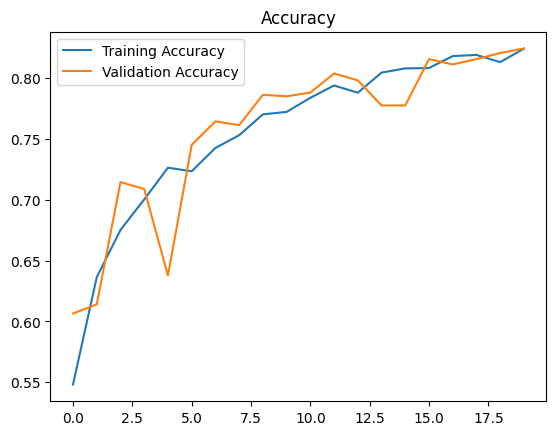

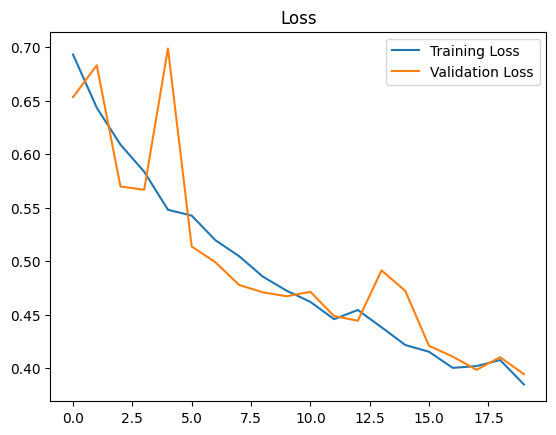

In [14]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure()
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.figure()
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()

In [15]:
#GlobalAveragePooling
#Tüm bir haritayı (kanalı) tek bir sayıya dönüştürür. Her channel için ortalama alır. Parametre düşer.

from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 31s 144ms/step - accuracy: 0.5167 - loss: 0.6931 - val_accuracy: 0.5503 - val_loss: 0.6829
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.5712 - loss: 0.6798 - val_accuracy: 0.5865 - val_loss: 0.6629
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.6011 - loss: 0.6574 - val_accuracy: 0.6052 - val_loss: 0.6529
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.6306 - loss: 0.6450 - val_accuracy: 0.6527 - val_loss: 0.6323
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.6273 - loss: 0.6423 - val_accuracy: 0.6309 - val_loss: 0.6371
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - accuracy: 0.6438 - loss: 0.6292 - val_accuracy: 0.6340 - val_loss: 0.6358
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 27s 137ms/step - accuracy: 0.6697 - loss: 0.6121 - val_accuracy: 0.6783 - val_loss: 0.6011
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - accuracy: 0.6491 - loss: 0

In [17]:
#Batch Normalization
#Ağ içindeki her bir "batch" (grup) veri için şu matematiksel işlemi yapar: Verinin ortalamasını alır.
#Verinin standart sapmasını (dağılımını) hesaplar. Verileri bu değerleri kullanarak normalize eder (genellikle ortalaması 0, standart sapması 1 olacak şekilde).

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])



In [18]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.5661 - loss: 0.7889 - val_accuracy: 0.4922 - val_loss: 0.7608
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.5928 - loss: 0.7037 - val_accuracy: 0.5465 - val_loss: 0.7125
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.6306 - loss: 0.6601 - val_accuracy: 0.5197 - val_loss: 0.8012
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.6406 - loss: 0.6412 - val_accuracy: 0.6396 - val_loss: 0.6761
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.6663 - loss: 0.6108 - val_accuracy: 0.5384 - val_loss: 0.9556
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.6705 - loss: 0.6104 - val_accuracy: 0.5621 - val_loss: 1.0369
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6791 - loss: 0.5917 - val_accuracy: 0.6115 - val_loss: 0.6451
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.6944 - loss: 0

In [19]:
#ReduceLROnPlateau
#model eğitimi sırasında öğrenmenin durakladığı anları fark eder ve öğrenme oranını otomatik olarak düşürür

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5, # Yeni LR = Eski LR * factor, öğrenme oranını 5 kat düşürür
    patience=2,
    min_lr=1e-6, #Öğrenme oranının düşebileceği en alt sınır
    verbose=1
)

FinishHistory=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.7219 - loss: 0.5371 - val_accuracy: 0.7270 - val_loss: 0.5307 - learning_rate: 0.0010
Epoch 2/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.7288 - loss: 0.5405 - val_accuracy: 0.6002 - val_loss: 0.8370 - learning_rate: 0.0010
Epoch 3/25
200/201 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.7242 - loss: 0.5426
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 144ms/step - accuracy: 0.7243 - loss: 0.5425 - val_accuracy: 0.6896 - val_loss: 0.5842 - learning_rate: 0.0010
Epoch 4/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.7454 - loss: 0.5176 - val_accuracy: 0.6140 - val_loss: 0.8131 - learning_rate: 5.0000e-04
Epoch 5/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - accuracy: 0.7433 - loss: 0.5138 - val_accuracy: 0.7502 - val_loss: 0.5035 - learning_rate: 5.0000e-04
Epoch 6/25
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accurac

In [20]:
#DropOut
model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 32s 144ms/step - accuracy: 0.5594 - loss: 0.7551 - val_accuracy: 0.4916 - val_loss: 0.8880
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.6123 - loss: 0.6681 - val_accuracy: 0.5846 - val_loss: 0.6756
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6327 - loss: 0.6490 - val_accuracy: 0.5728 - val_loss: 0.6999
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6486 - loss: 0.6312 - val_accuracy: 0.5440 - val_loss: 0.9442
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.6786 - loss: 0.5995 - val_accuracy: 0.5578 - val_loss: 0.9200
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.6832 - loss: 0.5978 - val_accuracy: 0.5297 - val_loss: 1.3190
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 171ms/step - accuracy: 0.6904 - loss: 0.5868 - val_accuracy: 0.5091 - val_loss: 2.5339


In [21]:
#Learning Rate Tuning

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 145ms/step - accuracy: 0.5788 - loss: 0.7642 - val_accuracy: 0.4916 - val_loss: 0.8591
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.6061 - loss: 0.6820 - val_accuracy: 0.5265 - val_loss: 0.7488
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6352 - loss: 0.6478 - val_accuracy: 0.6421 - val_loss: 0.6345
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6382 - loss: 0.6356 - val_accuracy: 0.5422 - val_loss: 1.2430
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6725 - loss: 0.6048 - val_accuracy: 0.6090 - val_loss: 0.6554
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6845 - loss: 0.5937 - val_accuracy: 0.6814 - val_loss: 0.5959
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 145ms/step - accuracy: 0.6825 - loss: 0.5895 - val_accuracy: 0.6802 - val_loss: 0.6280
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.6927 - loss: 0

In [22]:
#son deneme

model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(128,3,padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 147ms/step - accuracy: 0.5649 - loss: 0.7497 - val_accuracy: 0.4916 - val_loss: 0.8550
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 41s 147ms/step - accuracy: 0.6049 - loss: 0.6930 - val_accuracy: 0.4916 - val_loss: 1.2618
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.6011 - loss: 0.6896 - val_accuracy: 0.5309 - val_loss: 0.8969
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.6117 - loss: 0.6708 - val_accuracy: 0.5753 - val_loss: 0.7920
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6043 - loss: 0.6915 - val_accuracy: 0.5890 - val_loss: 0.7313
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6079 - loss: 0.6844 - val_accuracy: 0.6040 - val_loss: 0.7366
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.6275 - loss: 0.6515 - val_accuracy: 0.6227 - val_loss: 0.7000
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - accuracy: 0.6171 - loss: 0

- BatchNorm neden ReLU’dan önce?
BatchNorm ne yapıyor?
Çıktının ortalamasını 0’a yaklaştırır. Standart sapmasını 1’e yaklaştırır. Aktivasyonları stabilize eder

Eğer ReLU’dan sonra BN olursa:
ReLU negatifleri sıfırlar → dağılım bozulur. Sonra BN tekrar normalize etmeye çalışır. Bu stabil değildir.

BN, aktivasyondan önce dağılımı düzenler. Sonra ReLU temiz, dengeli veri alır.
Bu yüzden doğru sıralama: Conv → BN → ReLU

- Dropout neden BN’den sonra?
BatchNorm istatistik hesaplar: Ortalama, Varyans

Dropout önce olursa: Rastgele nöronlar kapanır. Dağılım her batch’te değişir. BN'nin hesapladığı istatistikler tutarsız olur. Bu modelin öğrenmesini zorlaştırır.

Doğru sıra: Conv → BN → ReLU → Dropout


In [23]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.flatten())

cm = confusion_matrix(y_true, y_pred)
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━

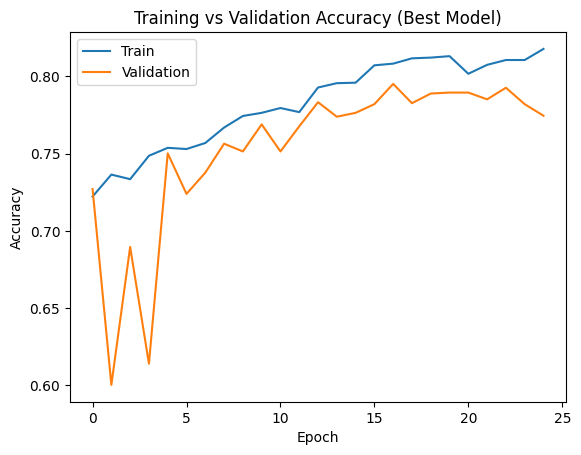

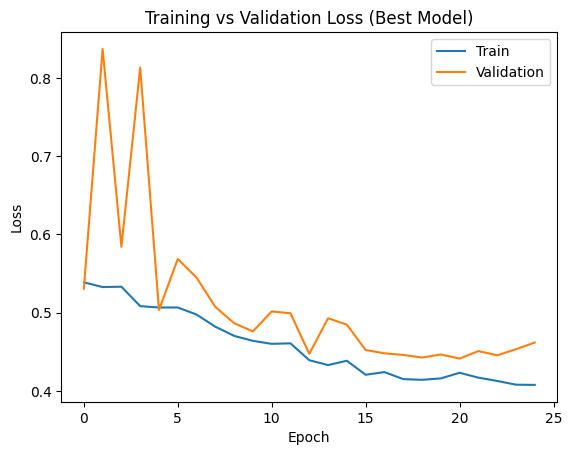

In [24]:
import matplotlib.pyplot as plt

acc = FinishHistory.history["accuracy"]
val_acc = FinishHistory.history["val_accuracy"]

loss = FinishHistory.history["loss"]
val_loss = FinishHistory.history["val_loss"]

epochs_range = range(len(acc))

# Accuracy Graph
plt.figure()
plt.plot(epochs_range, acc)
plt.plot(epochs_range, val_acc)
plt.title("Training vs Validation Accuracy (Best Model)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss Graph
plt.figure()
plt.plot(epochs_range, loss)
plt.plot(epochs_range, val_loss)
plt.title("Training vs Validation Loss (Best Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [25]:
import pandas as pd

results = {
    "Model": [
        "Basic CNN",
        "CNN + GlobalAveragePooling",
        "CNN + BatchNorm",
        "CNN + LR Scheduler (Best)",
        "Low LR (1e-4)"
    ],
    "Learning Rate": [
        0.001,
        0.001,
        0.001,
        0.001,
        0.0001
    ],
    "ReduceLROnPlateau": [
        "No",
        "No",
        "No",
        "Yes",
        "No"
    ],
    "Best Val Accuracy": [
        0.74,
        0.76,
        0.79,
        0.818,
        0.65
    ]
}

df = pd.DataFrame(results)
df

,Model,Learning Rate,ReduceLROnPlateau,Best Val Accuracy
0,Basic CNN,0.0010,No,0.740
1,CNN + GlobalAveragePooling,0.0010,No,0.760
2,CNN + BatchNorm,0.0010,No,0.790
3,CNN + LR Scheduler (Best),0.0010,Yes,0.818
4,Low LR (1e-4),0.0001,No,0.650


Found 2023 files belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1

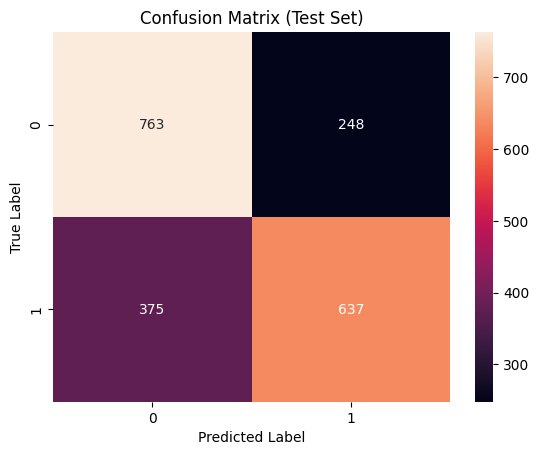

In [27]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf # Import tensorflow to use image_dataset_from_directory

# Define test_ds using test_dir, which is available from previous cells
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(150, 150),
    batch_size=32,
    shuffle=False # Typically, test sets are not shuffled
)

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.flatten())

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()